In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


df = pd.read_csv("/content/Chrysal_Dataset_Year_Month_4.csv")


In [37]:
df.head()

,Country,Product_Reference,Category,Marketing_Campaign_Type,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg,Year_Month
0,Holanda,Chrysal Grow X,Fungicida,Social Media,20893,6751.0,127316.56,57858.21,69458.35,18.86,750.32,2024-Febrero
1,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,6955,NaN,28100.09,18200.66,9899.44,NaN,209.94,2025-Enero
2,Ecuador,Chrysal Flora F,Insecticida,Social Media,34287,NaN,222096.76,101783.75,120313.01,NaN,882.49,2022-Mayo
3,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,21763,6751.0,114488.78,73680.46,40808.32,16.96,982.56,2024-Mayo
4,Colombia,Chrysal Grow X,Insecticida,Field Campaign,21736,6751.0,140394.64,78617.18,61777.45,20.80,582.48,2024-Abril


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   700 non-null    object 
 1   Product_Reference         700 non-null    object 
 2   Category                  700 non-null    object 
 3   Marketing_Campaign_Type   700 non-null    object 
 4   Sales_Units               700 non-null    int64  
 5   Marketing_Investment_USD  346 non-null    float64
 6   Sales_Revenue_USD         630 non-null    float64
 7   Production_Cost_USD       700 non-null    float64
 8   Gross_Margin_USD          700 non-null    float64
 9   Marketing_ROI             346 non-null    float64
 10  Waste_Generated_kg        665 non-null    float64
 11  Year_Month                700 non-null    object 
dtypes: float64(6), int64(1), object(5)
memory usage: 65.8+ KB


In [39]:
df.describe()

,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg
count,700.000000,346.0,630.000000,700.000000,700.000000,346.000000,665.000000
mean,18357.522857,6751.0,94651.089063,51202.551386,42214.134186,13.423584,914.770075
std,9812.482659,0.0,51459.167383,29005.844290,24410.604150,7.666074,616.570450
min,882.000000,6751.0,4838.780000,2103.090000,1608.130000,0.550000,24.210000
25%,10406.500000,6751.0,52970.632500,27831.665000,23095.720000,7.070000,404.660000
50%,19521.000000,6751.0,95928.995000,51334.860000,42157.950000,14.005000,806.690000
75%,26854.000000,6751.0,134256.020000,73362.980000,59170.692500,19.542500,1312.180000
max,34948.000000,6751.0,222096.760000,135566.840000,120313.010000,29.410000,2737.920000


In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df_clean = df.copy()

In [42]:
#df_clean["Year_Month_REV"] = pd.to_datetime(df["Year_Month"], errors="coerce", utc=True)
#df["fecha_dt"] = pd.to_datetime(df["fecha_en"], format="%Y-%B")

Validacion de cambio de tipo de dato para "Year_Month"

In [43]:
print(df_clean.dtypes)

Country                      object
Product_Reference            object
Category                     object
Marketing_Campaign_Type      object
Sales_Units                   int64
Marketing_Investment_USD    float64
Sales_Revenue_USD           float64
Production_Cost_USD         float64
Gross_Margin_USD            float64
Marketing_ROI               float64
Waste_Generated_kg          float64
Year_Month                   object
dtype: object


In [44]:
df_clean["Year_Month"].isna().sum()


np.int64(0)

In [45]:
df["Year_Month"].isna().sum()

np.int64(0)

In [46]:
#df_clean["Year"]  = df_clean["Year_Month"].dt.year
#df_clean["Month"] = df_clean["Year_Month"].dt.month

Se cambia el formato de fecha de "Year_Month" dde object a fecha con ".dateTime" y asi poder manejarar el set de datos por el año de interes




In [47]:
month_mapping = {
    'Enero': '01', 'Febrero': '02', 'Marzo': '03', 'Abril': '04',
    'Mayo': '05', 'Junio': '06', 'Julio': '07', 'Agosto': '08',
    'Septiembre': '09', 'Octubre': '10', 'Noviembre': '11', 'Diciembre': '12'
}

# Split the 'Year_Month' column into year string and month name
df_clean[['Year_str', 'Month_name']] = df_clean['Year_Month'].str.split('-', expand=True)

# Map the month names to numerical strings
df_clean['Month_num_str'] = df_clean['Month_name'].map(month_mapping)

# Combine year and month number to create a new date string in 'YYYY-MM-DD' format (using '01' for day)
df_clean['Formatted_Date'] = df_clean['Year_str'] + '-' + df_clean['Month_num_str'] + '-01'

# Convert the new date string to datetime objects
df_clean['Year_Month_dt'] = pd.to_datetime(df_clean['Formatted_Date'])

# Extract Year and Month
df_clean['Year'] = df_clean['Year_Month_dt'].dt.year
df_clean['Month'] = df_clean['Year_Month_dt'].dt.month

# Drop the intermediate columns used for conversion
df_clean = df_clean.drop(columns=['Year_str', 'Month_name', 'Month_num_str', 'Formatted_Date', 'Year_Month_dt'])

display(df_clean.head())

,Country,Product_Reference,Category,Marketing_Campaign_Type,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg,Year_Month,Year,Month
0,Holanda,Chrysal Grow X,Fungicida,Social Media,20893,6751.0,127316.56,57858.21,69458.35,18.86,750.32,2024-Febrero,2024,2
1,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,6955,NaN,28100.09,18200.66,9899.44,NaN,209.94,2025-Enero,2025,1
2,Ecuador,Chrysal Flora F,Insecticida,Social Media,34287,NaN,222096.76,101783.75,120313.01,NaN,882.49,2022-Mayo,2022,5
3,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,21763,6751.0,114488.78,73680.46,40808.32,16.96,982.56,2024-Mayo,2024,5
4,Colombia,Chrysal Grow X,Insecticida,Field Campaign,21736,6751.0,140394.64,78617.18,61777.45,20.80,582.48,2024-Abril,2024,4


In [48]:
month_names_english = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

df_clean['Month_Name_English'] = df_clean['Month'].map(month_names_english)

display(df_clean.head())

,Country,Product_Reference,Category,Marketing_Campaign_Type,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg,Year_Month,Year,Month,Month_Name_English
0,Holanda,Chrysal Grow X,Fungicida,Social Media,20893,6751.0,127316.56,57858.21,69458.35,18.86,750.32,2024-Febrero,2024,2,February
1,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,6955,NaN,28100.09,18200.66,9899.44,NaN,209.94,2025-Enero,2025,1,January
2,Ecuador,Chrysal Flora F,Insecticida,Social Media,34287,NaN,222096.76,101783.75,120313.01,NaN,882.49,2022-Mayo,2022,5,May
3,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,21763,6751.0,114488.78,73680.46,40808.32,16.96,982.56,2024-Mayo,2024,5,May
4,Colombia,Chrysal Grow X,Insecticida,Field Campaign,21736,6751.0,140394.64,78617.18,61777.45,20.80,582.48,2024-Abril,2024,4,April


In [49]:
df_clean.head()

,Country,Product_Reference,Category,Marketing_Campaign_Type,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg,Year_Month,Year,Month,Month_Name_English
0,Holanda,Chrysal Grow X,Fungicida,Social Media,20893,6751.0,127316.56,57858.21,69458.35,18.86,750.32,2024-Febrero,2024,2,February
1,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,6955,NaN,28100.09,18200.66,9899.44,NaN,209.94,2025-Enero,2025,1,January
2,Ecuador,Chrysal Flora F,Insecticida,Social Media,34287,NaN,222096.76,101783.75,120313.01,NaN,882.49,2022-Mayo,2022,5,May
3,Kenya,Chrysal Flora F,Nutricional,Influencers Agrícolas,21763,6751.0,114488.78,73680.46,40808.32,16.96,982.56,2024-Mayo,2024,5,May
4,Colombia,Chrysal Grow X,Insecticida,Field Campaign,21736,6751.0,140394.64,78617.18,61777.45,20.80,582.48,2024-Abril,2024,4,April


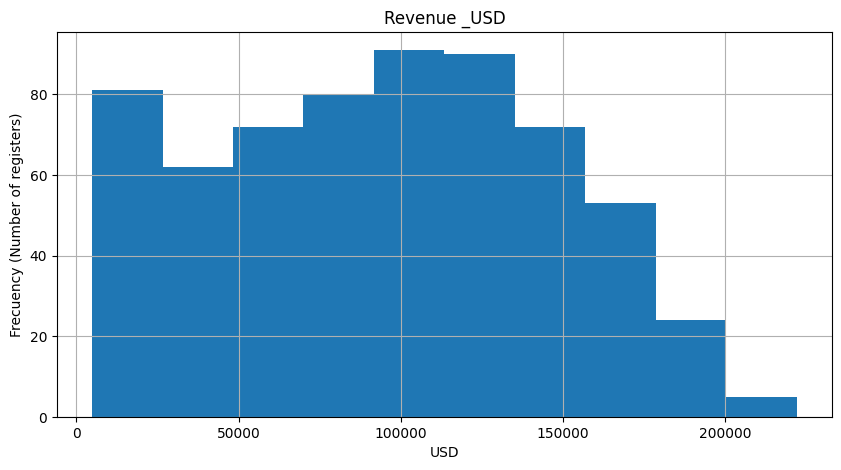

In [50]:
df_clean['Sales_Revenue_USD'].hist(bins=10, figsize=(10, 5)) # figsize=(ancho, alto)
plt.title('Revenue _USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

In [51]:
df_col = df_clean[(df_clean['Country']=='Colombia')
]
df_col

,Country,Product_Reference,Category,Marketing_Campaign_Type,Sales_Units,Marketing_Investment_USD,Sales_Revenue_USD,Production_Cost_USD,Gross_Margin_USD,Marketing_ROI,Waste_Generated_kg,Year_Month,Year,Month,Month_Name_English
4,Colombia,Chrysal Grow X,Insecticida,Field Campaign,21736,6751.0,140394.64,78617.18,61777.45,20.80,582.48,2024-Abril,2024,4,April
5,Colombia,Chrysal Grow X,Insecticida,Social Media,5226,NaN,33108.23,21276.40,11831.83,NaN,158.42,2025-Febrero,2025,2,February
11,Colombia,Chrysal Root R,Regulador de crecimiento,Social Media,25570,6751.0,116010.19,57025.59,58984.61,17.18,1301.98,2024-Febrero,2024,2,February
13,Colombia,Chrysal Root R,Nutricional,E-mail Marketing,3004,NaN,NaN,7113.15,7942.00,NaN,NaN,2024-Abril,2024,4,April
21,Colombia,Chrysal Grow X,Nutricional,E-mail Marketing,12708,6751.0,54370.16,31940.24,22429.91,8.05,902.99,2022-Marzo,2022,3,March
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
682,Colombia,Chrysal Flora F,Fungicida,Influencers Agrícolas,7659,6751.0,44753.43,27843.78,16909.64,6.63,392.94,2024-Mayo,2024,5,May
692,Colombia,Chrysal Grow X,Regulador de crecimiento,Social Media,29253,6751.0,164268.83,92471.52,71797.31,24.33,2175.43,2022-Mayo,2022,5,May
695,Colombia,Chrysal Boost Z,Fertilizante,Influencers Agrícolas,28669,6751.0,134575.02,74479.46,60095.57,19.93,605.26,2025-Febrero,2025,2,February
698,Colombia,Chrysal Flora F,Insecticida,E-mail Marketing,32509,NaN,180848.44,91872.60,88975.84,NaN,2069.15,2023-Marzo,2023,3,March


In [52]:
#df_clean=df_clean[
#(df_clean.groupby("Country")["Sales_Revenue_USD"].mean().reset_index().sort_values(by="Sales_Revenue_USD")) &
#    (df_clean['Year_Month'])
#]
#df_clean

Este conteo por paises nos permite ver que los informacion de paises esta bien porque la suma es 630 y es el total de valores esperados. De igual forma se podria confirmar con "unique" df["country_id"].dropna().unique()

In [53]:
df_clean.groupby("Country")["Sales_Revenue_USD"].mean().reset_index().sort_values(by="Sales_Revenue_USD")

,Country,Sales_Revenue_USD
2,Holanda,93438.857421
1,Ecuador,93790.497600
3,Kenya,94683.535442
0,Colombia,96923.429463


In [54]:
#df_target = df_clean[
##    (df_clean["value"] > 50) &
##    (df_clean["owner_name"].str.contains("government", case=False)) &
##    (df_clean["country_id"].isin(["KOR", "IND", "IDN"]))
##]
##df_target

In [55]:
##df_target = df[
##    (df_clean["value"] > 50) &
##    (df_clean["owner_name"].str.contains("government", case=False)) &
##    (df_clean["country_id"].isin(["KOR", "IND", "IDN"]))
##]
##df_target

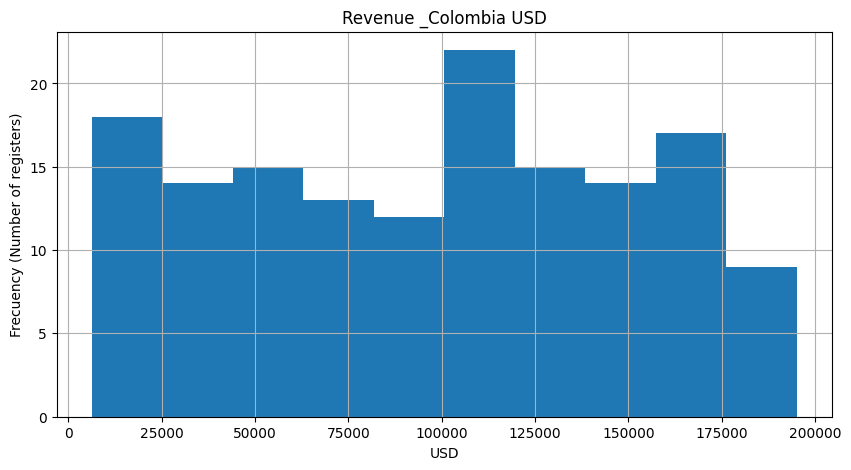

In [56]:
df_col['Sales_Revenue_USD'].hist(bins=10, figsize=(10, 5)) # figsize=(ancho, alto)
plt.title('Revenue _Colombia USD')
plt.xlabel('USD')
plt.ylabel('Frecuency (Number of registers)')
plt.show()

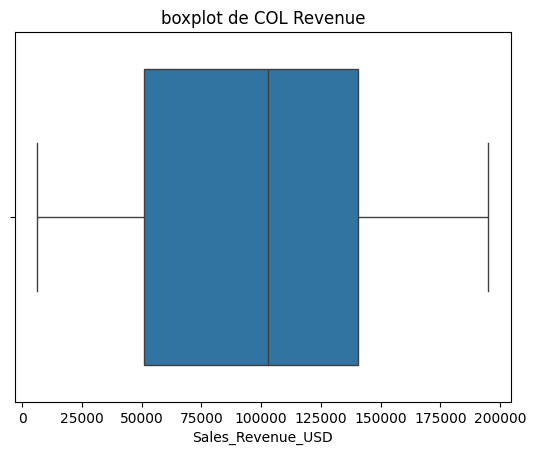

In [57]:
sns.boxplot(data=df_col, x="Sales_Revenue_USD")
plt.title(f'boxplot de COL Revenue')
plt.show()

In [58]:
df_clean.isna().sum()

,0
Country,0
Product_Reference,0
Category,0
Marketing_Campaign_Type,0
Sales_Units,0
Marketing_Investment_USD,354
Sales_Revenue_USD,70
Production_Cost_USD,0
Gross_Margin_USD,0
Marketing_ROI,354


Como ya identificamos las columnas claves "Sales_Revenue_USD" y "Waste_Generated_kg". Evidenciamos que el 10% de datos de "Sales_Revenue_USD" están vacíos y que según las pruebas de validación con la función ".describe()" y la visualización de histograma y boxplot vemos que no hay datos "aberrantes" o "Outliers" por esta razon procederemos a completar los datos con el promedio a travez de la funcion "fillna.mean()"

In [60]:
average = df_clean["Sales_Revenue_USD"].mean()
df_clean["Sales_Revenue_USD"] = df_clean["Sales_Revenue_USD"].fillna(average)


In [61]:
# Nulos en 'Sales_Revenue' después de reemplazar (debería ser 0)
df_clean["Sales_Revenue_USD"].isna().sum()

np.int64(0)

In [62]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Country                   700 non-null    object 
 1   Product_Reference         700 non-null    object 
 2   Category                  700 non-null    object 
 3   Marketing_Campaign_Type   700 non-null    object 
 4   Sales_Units               700 non-null    int64  
 5   Marketing_Investment_USD  346 non-null    float64
 6   Sales_Revenue_USD         700 non-null    float64
 7   Production_Cost_USD       700 non-null    float64
 8   Gross_Margin_USD          700 non-null    float64
 9   Marketing_ROI             346 non-null    float64
 10  Waste_Generated_kg        665 non-null    float64
 11  Year_Month                700 non-null    object 
 12  Year                      700 non-null    int32  
 13  Month                     700 non-null    int32  
 14  Month_Name